<a href="https://colab.research.google.com/github/ToasterToucher/Data201/blob/main/Week_2_Exercises_8_9_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data 201 - Week 2 Assignment
## ISLP Chapter 2, Applied Exercises 8, 9 and 10

All figures quoted in the written responses were produced by the cells in
this notebook.

In [ ]:
!pip install ISLP --quiet

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 25.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.6/84.6 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.0/853.0 kB 39.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 43.5 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

BASE = "/content/drive/MyDrive/Data_201/Datasets/"


Mounted at /content/drive


---
# Exercise 8 - College data set

777 US colleges and universities, 18 variables covering admissions, costs,
faculty and outcomes.

### 8(a) Read the data

In [ ]:
college = pd.read_csv(BASE + "College.csv")
college.head()

,Unnamed: 0,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
3,Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
4,Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


### 8(b) Fix the index

School names arrive in a column called `Unnamed: 0`, which pandas treats as
ordinary data. Moving it to the index keeps the names available for
labelling without letting them interfere with numeric operations.

In [ ]:
college2 = pd.read_csv(BASE + "College.csv", index_col=0)

college3 = college.rename({'Unnamed: 0': 'College'}, axis=1)
college3 = college3.set_index('College')

college = college3
college.head()

,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
College,,,,,,,,,,,,,,,,,,
Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


In [ ]:
print("shape:", college.shape)
print()
print(college.dtypes)

shape: (777, 18)

Private         object
Apps             int64
Accept           int64
Enroll           int64
Top10perc        int64
Top25perc        int64
F.Undergrad      int64
P.Undergrad      int64
Outstate         int64
Room.Board       int64
Books            int64
Personal         int64
PhD              int64
Terminal         int64
S.F.Ratio      float64
perc.alumni      int64
Expend           int64
Grad.Rate        int64
dtype: object


777 rows and 18 columns after indexing. `Private` is the only
non-numeric column, stored as `Yes` / `No`.

### 8(c) Numerical summary

In [ ]:
college.describe()

,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
count,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.00000
mean,3001.638353,2018.804376,779.972973,27.558559,55.796654,3699.907336,855.298584,10440.669241,4357.526384,549.380952,1340.642214,72.660232,79.702703,14.089704,22.743887,9660.171171,65.46332
std,3870.201484,2451.113971,929.176190,17.640364,19.804778,4850.420531,1522.431887,4023.016484,1096.696416,165.105360,677.071454,16.328155,14.722359,3.958349,12.391801,5221.768440,17.17771
min,81.000000,72.000000,35.000000,1.000000,9.000000,139.000000,1.000000,2340.000000,1780.000000,96.000000,250.000000,8.000000,24.000000,2.500000,0.000000,3186.000000,10.00000
25%,776.000000,604.000000,242.000000,15.000000,41.000000,992.000000,95.000000,7320.000000,3597.000000,470.000000,850.000000,62.000000,71.000000,11.500000,13.000000,6751.000000,53.00000
50%,1558.000000,1110.000000,434.000000,23.000000,54.000000,1707.000000,353.000000,9990.000000,4200.000000,500.000000,1200.000000,75.000000,82.000000,13.600000,21.000000,8377.000000,65.00000
75%,3624.000000,2424.000000,902.000000,35.000000,69.000000,4005.000000,967.000000,12925.000000,5050.000000,600.000000,1700.000000,85.000000,92.000000,16.500000,31.000000,10830.000000,78.00000
max,48094.000000,26330.000000,6392.000000,96.000000,100.000000,31643.000000,21836.000000,21700.000000,8124.000000,2340.000000,6800.000000,103.000000,100.000000,39.800000,64.000000,56233.000000,118.00000


In [ ]:
print("Grad.Rate max:", college["Grad.Rate"].max())
print()
print(college.loc[college["Grad.Rate"] > 100, ["Grad.Rate"]])

Grad.Rate max: 118

                   Grad.Rate
College                     
Cazenovia College        118


Exactly one school, Cazenovia College, reports a graduation rate of
118%. This is a known error in the data set.


### 8(d) Scatterplot matrix of the first columns

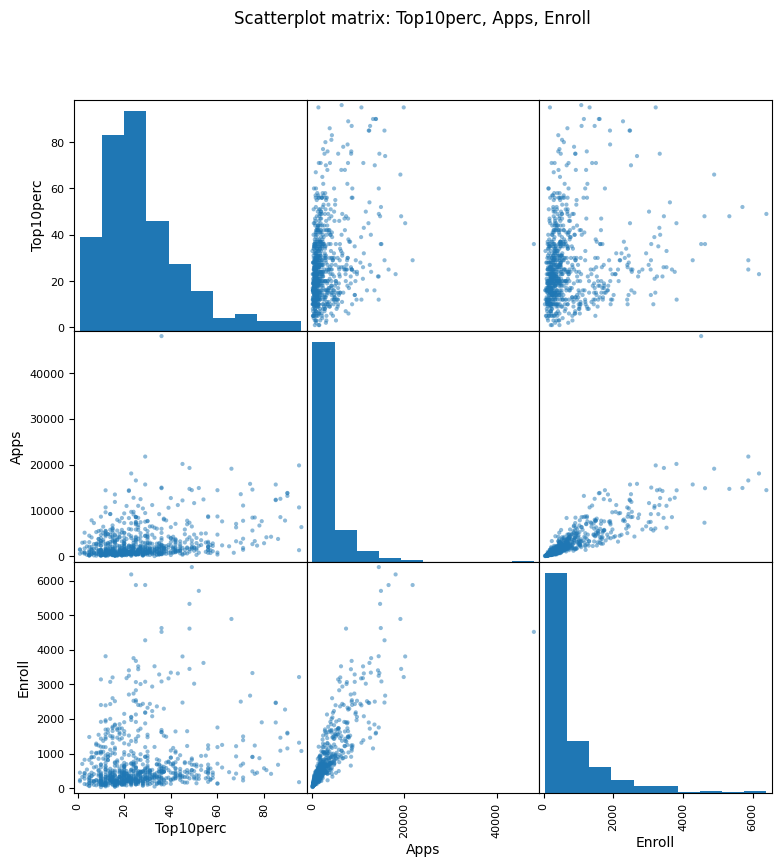

In [ ]:
pd.plotting.scatter_matrix(
    college[['Top10perc', 'Apps', 'Enroll']],
    figsize=(9, 9),
    alpha=0.5
)
plt.suptitle("Scatterplot matrix: Top10perc, Apps, Enroll")
plt.show()

In [ ]:
college[['Top10perc', 'Apps', 'Enroll']].corr().round(3)

,Top10perc,Apps,Enroll
Top10perc,1.000,0.339,0.181
Apps,0.339,1.000,0.847
Enroll,0.181,0.847,1.000


### 8(e) Boxplots of Outstate versus Private

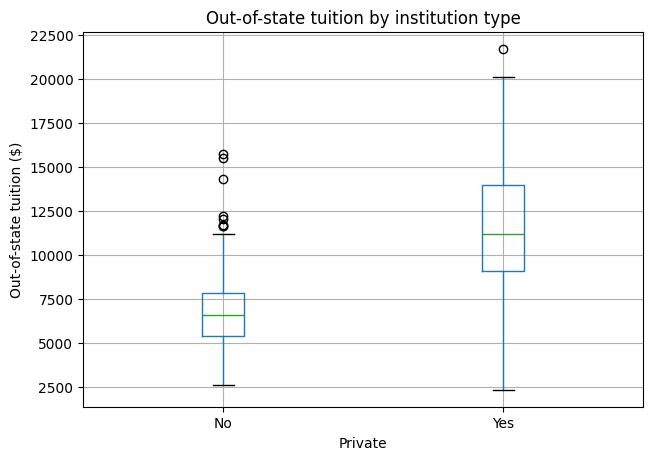

In [ ]:
college.boxplot(column='Outstate', by='Private', figsize=(7, 5))
plt.title("Out-of-state tuition by institution type")
plt.suptitle("")
plt.xlabel("Private")
plt.ylabel("Out-of-state tuition ($)")
plt.show()

In [ ]:
college.groupby("Private")["Outstate"].describe().round(1)

,count,mean,std,min,25%,50%,75%,max
Private,,,,,,,,
No,212.0,6813.4,2145.2,2580.0,5366.0,6609.0,7844.0,15732.0
Yes,565.0,11801.7,3707.5,2340.0,9100.0,11200.0,13970.0,21700.0


### 8(f) Create the Elite variable

The textbook gives bin edges of `[0, 0.5, 1]`, which assumes `Top10perc` is
a proportion. In this file it is a percentage running from 1 to 96.

In [ ]:
print("Top10perc range:", college["Top10perc"].min(), "to", college["Top10perc"].max())

book_version = pd.cut(college['Top10perc'], [0, 0.5, 1], labels=['No', 'Yes'])
print("NaN using the book's bin edges:", book_version.isna().sum(), "of", len(college))

Top10perc range: 1 to 96
NaN using the book's bin edges: 774 of 777


In [ ]:
college['Elite'] = pd.cut(
    college['Top10perc'],
    [0, 50, 100],
    labels=['No', 'Yes']
)

print(college['Elite'].value_counts())

Elite
No     699
Yes     78
Name: count, dtype: int64


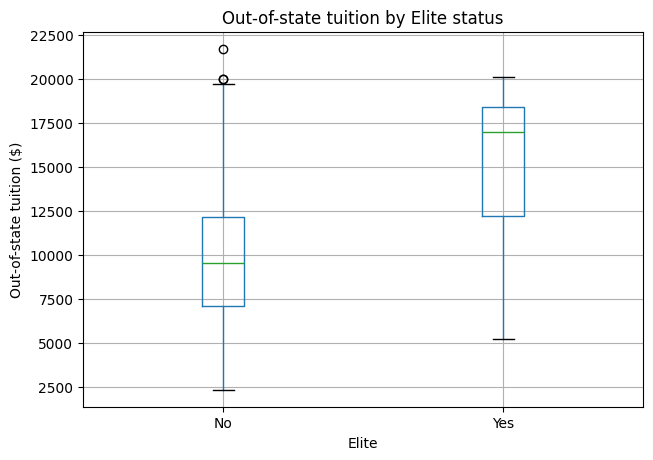

In [ ]:
college.boxplot(column='Outstate', by='Elite', figsize=(7, 5))
plt.title("Out-of-state tuition by Elite status")
plt.suptitle("")
plt.xlabel("Elite")
plt.ylabel("Out-of-state tuition ($)")
plt.show()

In [ ]:
print(college.groupby("Elite", observed=True)["Outstate"].describe().round(1))
print()
print("Elite vs Private:")
print(pd.crosstab(college["Elite"], college["Private"]))

       count     mean     std     min      25%      50%      75%      max
Elite                                                                    
No     699.0   9904.2  3640.6  2340.0   7070.0   9556.0  12155.0  21700.0
Yes     78.0  15248.6  4115.2  5224.0  12219.0  16950.0  18411.5  20100.0

Elite vs Private:
Private   No  Yes
Elite            
No       199  500
Yes       13   65


### 8(g) Histograms with differing bin counts

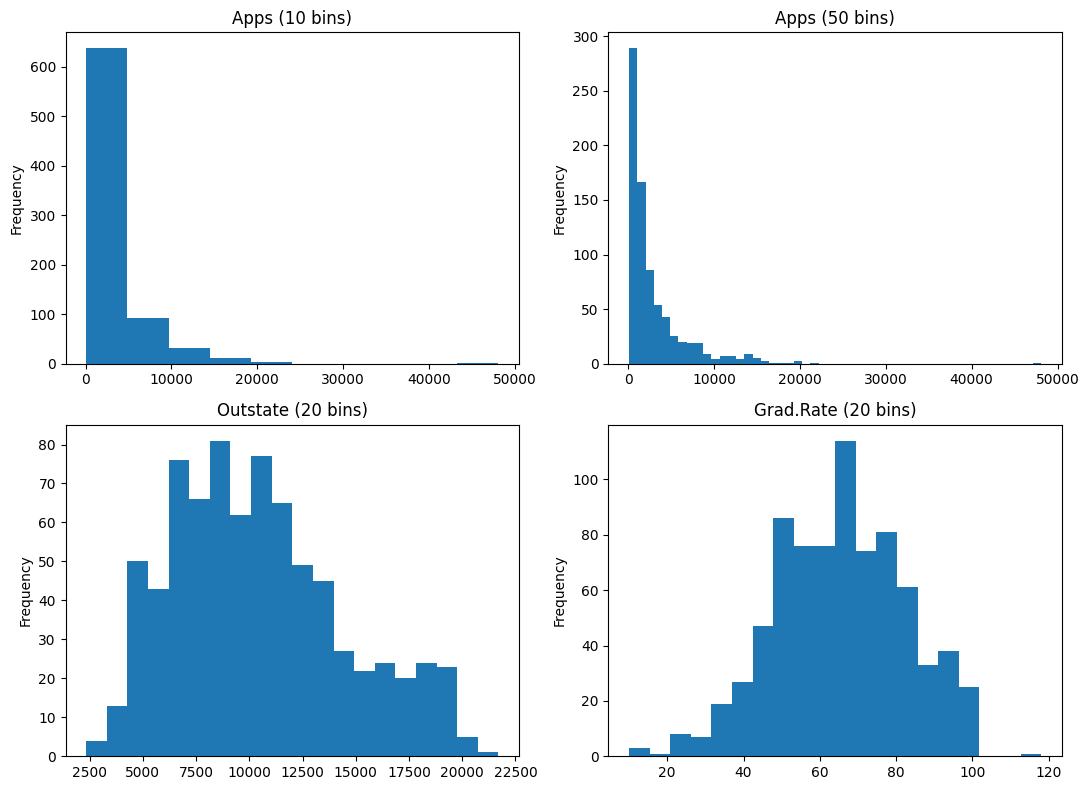

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

college['Apps'].plot.hist(bins=10, ax=axes[0, 0], title='Apps (10 bins)')
college['Apps'].plot.hist(bins=50, ax=axes[0, 1], title='Apps (50 bins)')
college['Outstate'].plot.hist(bins=20, ax=axes[1, 0], title='Outstate (20 bins)')
college['Grad.Rate'].plot.hist(bins=20, ax=axes[1, 1], title='Grad.Rate (20 bins)')

plt.tight_layout()
plt.show()

### 8(h) Continue exploring

In [ ]:
college["AcceptRate"] = college["Accept"] / college["Apps"]
college["YieldRate"] = college["Enroll"] / college["Accept"]

college[["AcceptRate", "YieldRate", "Grad.Rate", "Outstate", "S.F.Ratio", "Expend"]].describe().round(3)

,AcceptRate,YieldRate,Grad.Rate,Outstate,S.F.Ratio,Expend
count,777.000,777.000,777.000,777.000,777.000,777.000
mean,0.747,0.412,65.463,10440.669,14.090,9660.171
std,0.147,0.134,17.178,4023.016,3.958,5221.768
min,0.154,0.100,10.000,2340.000,2.500,3186.000
25%,0.676,0.317,53.000,7320.000,11.500,6751.000
50%,0.779,0.387,65.000,9990.000,13.600,8377.000
75%,0.849,0.486,78.000,12925.000,16.500,10830.000
max,1.000,1.000,118.000,21700.000,39.800,56233.000


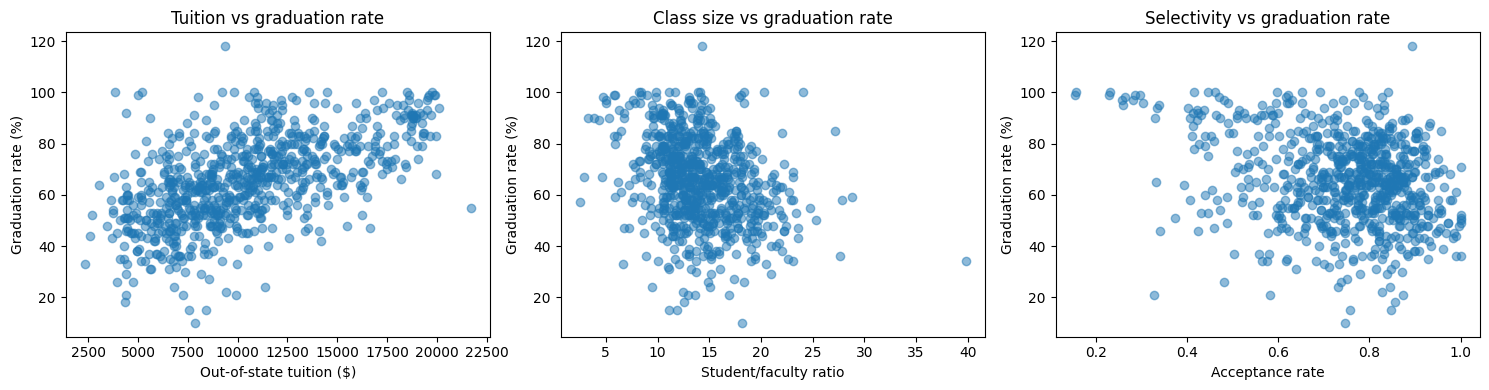

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(college["Outstate"], college["Grad.Rate"], alpha=0.5)
axes[0].set_xlabel("Out-of-state tuition ($)")
axes[0].set_ylabel("Graduation rate (%)")
axes[0].set_title("Tuition vs graduation rate")

axes[1].scatter(college["S.F.Ratio"], college["Grad.Rate"], alpha=0.5)
axes[1].set_xlabel("Student/faculty ratio")
axes[1].set_ylabel("Graduation rate (%)")
axes[1].set_title("Class size vs graduation rate")

axes[2].scatter(college["AcceptRate"], college["Grad.Rate"], alpha=0.5)
axes[2].set_xlabel("Acceptance rate")
axes[2].set_ylabel("Graduation rate (%)")
axes[2].set_title("Selectivity vs graduation rate")

plt.tight_layout()
plt.show()

In [ ]:
numeric_cols = college.select_dtypes(include=[np.number])
numeric_cols.corr()["Grad.Rate"].drop("Grad.Rate").sort_values(ascending=False).round(3)

,Grad.Rate
Outstate,0.571
Top10perc,0.495
perc.alumni,0.491
Top25perc,0.477
Room.Board,0.425
Expend,0.390
PhD,0.305
Terminal,0.290
Apps,0.147
Accept,0.067


**Written summary.**

Graduation rate is positively correlated with tuition for out-of-state students and percentage of alumni donors and negatively correlated with student/faculty ratio. Colleges accepting fewer students among those applied have higher student graduation rates.

While there are correlations, they are not high enough to predict graduation rate by one variable alone. They show a set of inter-correlated characteristics of institutions rather than independent factors.

And here comes an important note: none of the above correlations is causal. It is clear that tuition, selectivity, spending, and graduation rate correlate with each other partly because they are the results of institutional wealth and pre-college performance of the incoming class. The data does not allow distinguishing between college making its students better and simply choosing those who were about to graduate anyway.

---
# Exercise 9 - Auto data set

Fuel consumption and vehicle attributes for cars from 1970 to 1982.

### Load and remove missing values

`horsepower` stores missing entries as the literal string `"?"`. Passing
`na_values="?"` at read time converts them to proper nulls, after which the
column parses as numeric.

In [ ]:
Auto = pd.read_csv(BASE + "Auto.csv", na_values="?")

print("shape before dropping:", Auto.shape)
print("missing values:", Auto.isna().sum().sum())
print()
print(Auto.isna().sum())

shape before dropping: (397, 9)
missing values: 5

mpg             0
cylinders       0
displacement    0
horsepower      5
weight          0
acceleration    0
year            0
origin          0
name            0
dtype: int64


In [ ]:
Auto = Auto.dropna().reset_index(drop=True)

print("shape after dropping:", Auto.shape)
print()
print(Auto.dtypes)

shape after dropping: (392, 9)

mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight            int64
acceleration    float64
year              int64
origin            int64
name             object
dtype: object


397 rows load, 5 have missing horsepower, 392 remain. Without
`na_values="?"` the column would parse as text and `isna().sum()` would
report zero missing, which is the trap in the Week 2 lab.

### 9(a) Which predictors are quantitative, which are qualitative

In [ ]:
for col in Auto.columns:
    print(f"{col:15s} dtype={str(Auto[col].dtype):10s} unique={Auto[col].nunique()}")

mpg             dtype=float64    unique=127
cylinders       dtype=int64      unique=5
displacement    dtype=float64    unique=81
horsepower      dtype=float64    unique=93
weight          dtype=int64      unique=346
acceleration    dtype=float64    unique=95
year            dtype=int64      unique=13
origin          dtype=int64      unique=3
name            dtype=object     unique=301


**Written response.**

**Quantitative:** `mpg`, `displacement`, `horsepower`, `weight` and
`acceleration`. Each is a continuous measurement where the numeric value
carries magnitude, differences are meaningful, and an average makes sense.

**Qualitative:** `origin` and `name`. `origin` holds 1, 2 and 3 as labels
for USA, Europe and Japan, with no ordering or meaningful spacing. `name`
is a text identifier, and with 301 distinct values across 392 rows it is
close to a unique key.

### 9(b) Range of each quantitative predictor

In [ ]:
quant = ["mpg", "cylinders", "displacement", "horsepower", "weight", "acceleration"]

ranges = pd.DataFrame({
    "min": Auto[quant].min(),
    "max": Auto[quant].max()
})
ranges["range"] = ranges["max"] - ranges["min"]
ranges.round(3)

,min,max,range
mpg,9.0,46.6,37.6
cylinders,3.0,8.0,5.0
displacement,68.0,455.0,387.0
horsepower,46.0,230.0,184.0
weight,1613.0,5140.0,3527.0
acceleration,8.0,24.8,16.8


| Variable | Min | Max | Range |
|---|---|---|---|
| mpg | 9.0 | 46.6 | 37.6 |
| cylinders | 3 | 8 | 5 |
| displacement | 68 | 455 | 387 |
| horsepower | 46 | 230 | 184 |
| weight | 1613 | 5140 | 3527 |
| acceleration | 8.0 | 24.8 | 16.8 |

### 9(c) Mean and standard deviation of each

In [ ]:
summary = pd.DataFrame({
    "mean": Auto[quant].mean(),
    "std": Auto[quant].std()
}).round(3)
summary

,mean,std
mpg,23.446,7.805
cylinders,5.472,1.706
displacement,194.412,104.644
horsepower,104.469,38.491
weight,2977.584,849.403
acceleration,15.541,2.759


| Variable | Mean | Std |
|---|---|---|
| mpg | 23.446 | 7.805 |
| cylinders | 5.472 | 1.706 |
| displacement | 194.412 | 104.644 |
| horsepower | 104.469 | 38.491 |
| weight | 2977.584 | 849.403 |
| acceleration | 15.541 | 2.759 |

### 9(d) Remove observations 10 through 85

In [ ]:
Auto_subset = Auto.drop(Auto.index[9:85])

print("original rows:", Auto.shape[0])
print("removed:      ", Auto.shape[0] - Auto_subset.shape[0])
print("remaining:    ", Auto_subset.shape[0])

original rows: 392
removed:       76
remaining:     316


In [ ]:
subset_summary = pd.DataFrame({
    "min": Auto_subset[quant].min(),
    "max": Auto_subset[quant].max(),
    "mean": Auto_subset[quant].mean(),
    "std": Auto_subset[quant].std()
}).round(3)
subset_summary

,min,max,mean,std
mpg,11.0,46.6,24.404,7.867
cylinders,3.0,8.0,5.373,1.654
displacement,68.0,455.0,187.241,99.678
horsepower,46.0,230.0,100.722,35.709
weight,1649.0,4997.0,2935.972,811.300
acceleration,8.5,24.8,15.727,2.694


In [ ]:
comparison = pd.DataFrame({
    "mean_full": Auto[quant].mean(),
    "mean_subset": Auto_subset[quant].mean(),
    "std_full": Auto[quant].std(),
    "std_subset": Auto_subset[quant].std()
}).round(3)
comparison["mean_change"] = (comparison["mean_subset"] - comparison["mean_full"]).round(3)
comparison

,mean_full,mean_subset,std_full,std_subset,mean_change
mpg,23.446,24.404,7.805,7.867,0.958
cylinders,5.472,5.373,1.706,1.654,-0.099
displacement,194.412,187.241,104.644,99.678,-7.171
horsepower,104.469,100.722,38.491,35.709,-3.747
weight,2977.584,2935.972,849.403,811.300,-41.612
acceleration,15.541,15.727,2.759,2.694,0.186


**Written response.**

76 observations are removed, leaving 316.

| Variable | Min | Max | Mean | Std |
|---|---|---|---|---|
| mpg | 11.0 | 46.6 | 24.404 | 7.867 |
| cylinders | 3 | 8 | 5.373 | 1.654 |
| displacement | 68 | 455 | 187.241 | 99.678 |
| horsepower | 46 | 230 | 100.722 | 35.709 |
| weight | 1649 | 4997 | 2935.972 | 811.300 |
| acceleration | 8.5 | 24.8 | 15.727 | 2.694 |


### 9(e) Investigate the predictors graphically

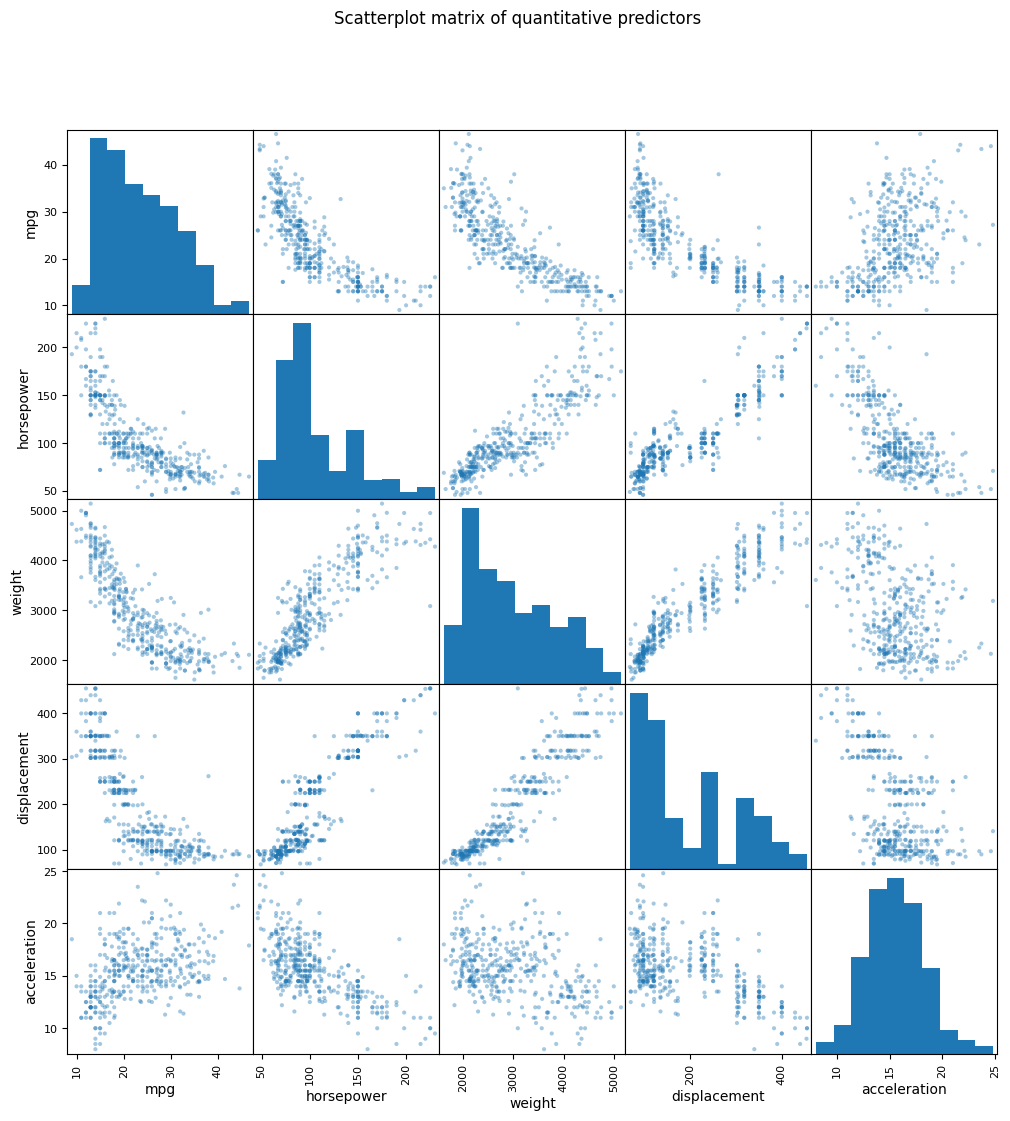

In [ ]:
pd.plotting.scatter_matrix(
    Auto[["mpg", "horsepower", "weight", "displacement", "acceleration"]],
    figsize=(12, 12),
    alpha=0.4
)
plt.suptitle("Scatterplot matrix of quantitative predictors")
plt.show()

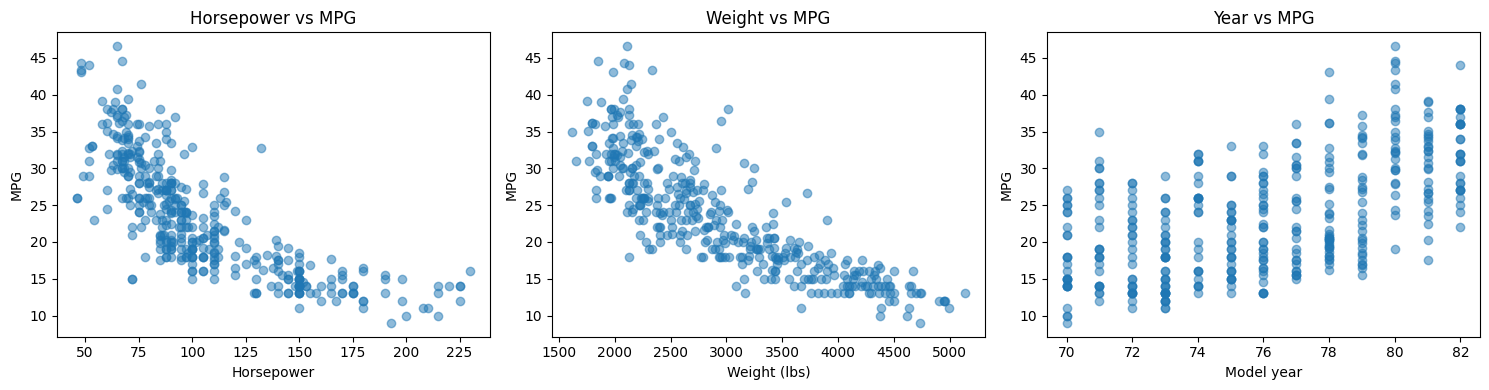

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(Auto["horsepower"], Auto["mpg"], alpha=0.5)
axes[0].set_xlabel("Horsepower"); axes[0].set_ylabel("MPG")
axes[0].set_title("Horsepower vs MPG")

axes[1].scatter(Auto["weight"], Auto["mpg"], alpha=0.5)
axes[1].set_xlabel("Weight (lbs)"); axes[1].set_ylabel("MPG")
axes[1].set_title("Weight vs MPG")

axes[2].scatter(Auto["year"], Auto["mpg"], alpha=0.5)
axes[2].set_xlabel("Model year"); axes[2].set_ylabel("MPG")
axes[2].set_title("Year vs MPG")

plt.tight_layout()
plt.show()

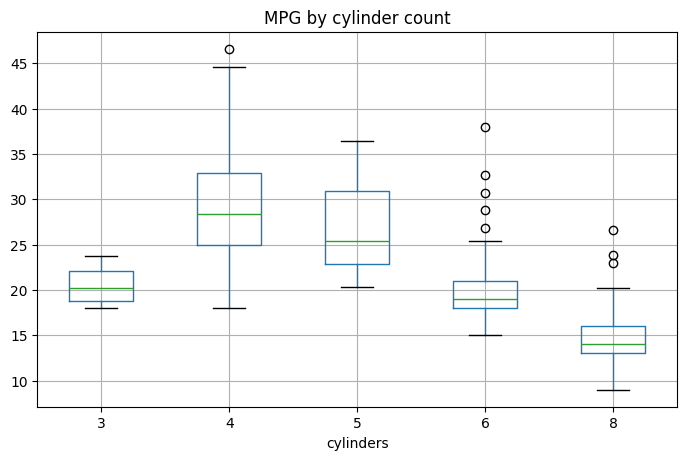

In [ ]:
Auto.boxplot(column="mpg", by="cylinders", figsize=(8, 5))
plt.title("MPG by cylinder count")
plt.suptitle("")
plt.show()

In [ ]:
Auto[quant + ["year", "origin"]].corr()["mpg"].drop("mpg").sort_values().round(3)

,mpg
weight,-0.832
displacement,-0.805
horsepower,-0.778
cylinders,-0.778
acceleration,0.423
origin,0.565
year,0.581


**Written response.**

Correlations with `mpg`:

| Variable | Correlation |
|---|---|
| weight | -0.832 |
| displacement | -0.805 |
| horsepower | -0.778 |
| cylinders | -0.778 |
| acceleration | +0.423 |
| origin | +0.565 |
| year | +0.581 |

mpg is negatively correlated with weight, displacement and horsepower, and all of them have curves. Horsepower vs mpg decreases from mid-40s to 15 for 50 to 150 horsepowers and flattens, then increases a bit beyond 200. Weight vs mpg does likewise and compresses very sharply above 4000 pounds. Linear models would lose both tails, so these correlations set a lower limit.

The three size parameters are highly correlated with each other. Horsepower vs weight and weight vs displacement have almost linear dependencies in the correlation matrix, so that they are in fact one signal, not three.

Year vs mpg increases, but in the form of widening, not shifting. The years 1970 to 1974 are in the 10 to 30 mpg band; 1980 to 1982 range is 20 to 45 mpg. The lower boundary grows significantly more than the upper one, so the change is mostly due to weak cars improving a little.

Cylinders boxplot splits into clear four bands the median of 4-cylinder is around 29, while for 8 cylinders it is near 15. But the 3 and 5 cylinders have little to no data points so their boxes cannot be trusted.

### 9(f) Which variables help predict mpg

**Written response.**

Yes. weight is the strongest at -0.832, followed by displacement at -0.805, horsepower and cylinders both at -0.778. However, year at +0.581 and origin at +0.565 are less strong, yet carry different meaning in that year represents how technology has evolved during the time span while not having anything to do with the car itself.

Two caveats. First, the relations are non-linear so that a linear regression using the unmodified variables works badly both at extremes. Using a regression on log(weight) or 1/weight should be tried first. Second, weight, displacement and horsepower are highly correlated so that using all of them makes the estimation unstable. Prediction will work fine, the interpretation won't.

---
# Exercise 10 - Boston housing data set


### 10(a) Load the data

In [ ]:
from ISLP import load_data

Boston = load_data("Boston")
Boston.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2


### 10(b) Rows, columns, and what they represent

In [ ]:
print("shape:", Boston.shape)
print()
print(Boston.dtypes)

shape: (506, 13)

crim       float64
zn         float64
indus      float64
chas         int64
nox        float64
rm         float64
age        float64
dis        float64
rad          int64
tax          int64
ptratio    float64
lstat      float64
medv       float64
dtype: object


**Written response.**

506 observations, 13 variables. Each observation is a census tract, not a single household, hence all the variables are aggregated. rm refers to the tract’s average number of rooms per dwelling. Variables include housing (rm, age, medv), neighborhood quality (crim, nox, chas, zn, indus), and accessibility and services (dis, rad, tax, ptratio, lstat).

Based on dtypes above, chas and rad have been stored as int64 while categorical in nature, where chas is dichotomous and rad is an ordinal categorical with 9 levels. tax is int64 and truly continuous variable. Storage type doesn’t reveal the underlying meaning of the data like the case with origin in Auto.

### 10(c) Pairwise scatterplots

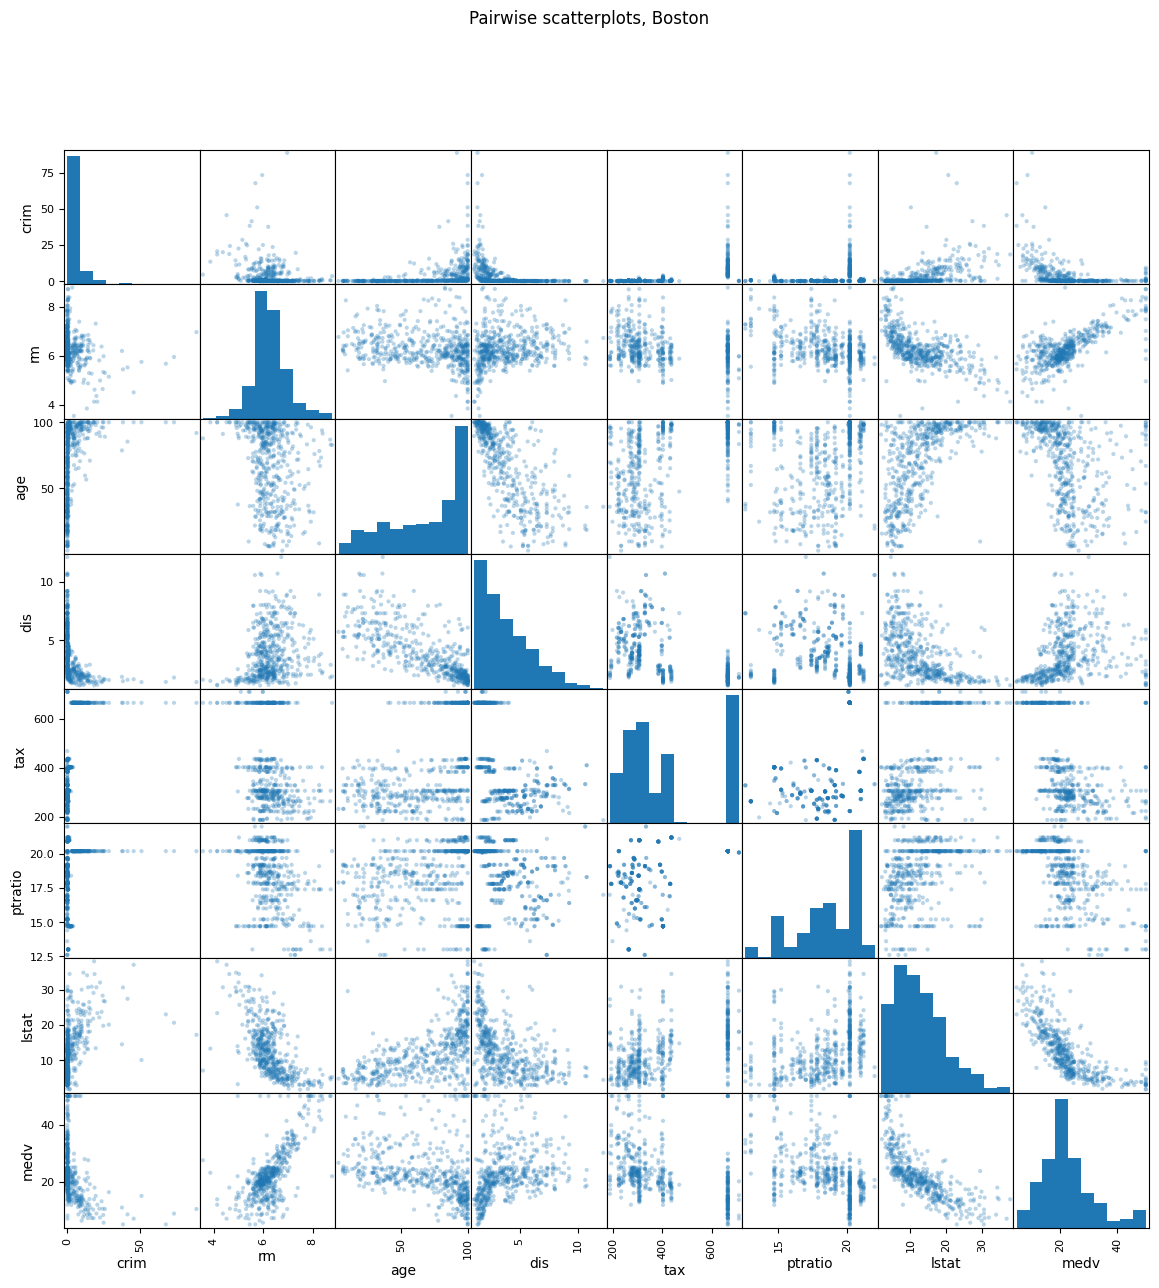

In [ ]:
subset_cols = ["crim", "rm", "age", "dis", "tax", "ptratio", "lstat", "medv"]

pd.plotting.scatter_matrix(
    Boston[subset_cols],
    figsize=(14, 14),
    alpha=0.3
)
plt.suptitle("Pairwise scatterplots, Boston")
plt.show()

In [ ]:
Boston.corr().round(2)

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
crim,1.00,-0.20,0.41,-0.06,0.42,-0.22,0.35,-0.38,0.63,0.58,0.29,0.46,-0.39
zn,-0.20,1.00,-0.53,-0.04,-0.52,0.31,-0.57,0.66,-0.31,-0.31,-0.39,-0.41,0.36
indus,0.41,-0.53,1.00,0.06,0.76,-0.39,0.64,-0.71,0.60,0.72,0.38,0.60,-0.48
chas,-0.06,-0.04,0.06,1.00,0.09,0.09,0.09,-0.10,-0.01,-0.04,-0.12,-0.05,0.18
nox,0.42,-0.52,0.76,0.09,1.00,-0.30,0.73,-0.77,0.61,0.67,0.19,0.59,-0.43
rm,-0.22,0.31,-0.39,0.09,-0.30,1.00,-0.24,0.21,-0.21,-0.29,-0.36,-0.61,0.70
age,0.35,-0.57,0.64,0.09,0.73,-0.24,1.00,-0.75,0.46,0.51,0.26,0.60,-0.38
dis,-0.38,0.66,-0.71,-0.10,-0.77,0.21,-0.75,1.00,-0.49,-0.53,-0.23,-0.50,0.25
rad,0.63,-0.31,0.60,-0.01,0.61,-0.21,0.46,-0.49,1.00,0.91,0.46,0.49,-0.38
tax,0.58,-0.31,0.72,-0.04,0.67,-0.29,0.51,-0.53,0.91,1.00,0.46,0.54,-0.47


**Written response.**

lstat-medv is at -0.74. The value falls rapidly as the lstat increases in the low range, and it evens out afterward. It is not linear, thus -0.74 is an understatement.

rm-medv has +0.70. Again, it is not linear as it spreads wide in the high range since tracts with the same average number of rooms have a wide range of values.

nox, indus, tax and age are a group of variables with correlation from 0.60 to 0.76. The industrial areas have higher pollution, taxes, and older homes. dis contradicts all of them as -0.77 with nox and -0.75 with age, implying that distance from centers of employment correlates with less industry and pollution.

rad-tax with +0.91 has the highest correlation in the matrix, but this is due to the 132-tract cluster once more.

### 10(d) Predictors associated with crime rate

In [ ]:
Boston.corr()["crim"].drop("crim").sort_values(ascending=False).round(3)

,crim
rad,0.626
tax,0.583
lstat,0.456
nox,0.421
indus,0.407
age,0.353
ptratio,0.290
chas,-0.056
zn,-0.200
rm,-0.219


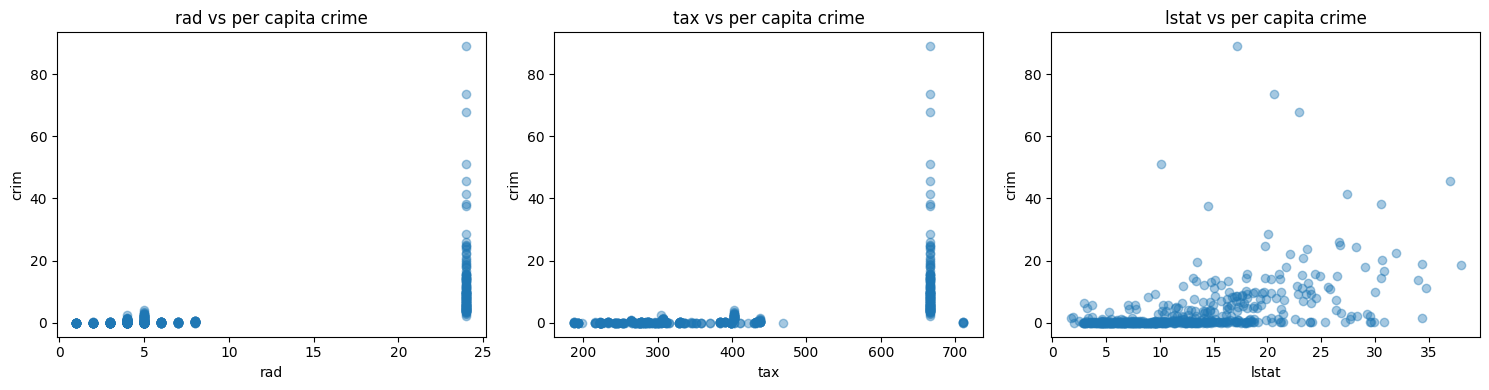

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, ["rad", "tax", "lstat"]):
    ax.scatter(Boston[col], Boston["crim"], alpha=0.4)
    ax.set_xlabel(col)
    ax.set_ylabel("crim")
    ax.set_title(f"{col} vs per capita crime")

plt.tight_layout()
plt.show()

**Written response.**

| Predictor | Correlation with crim |
|---|---|
| rad | +0.626 |
| tax | +0.583 |
| lstat | +0.456 |
| nox | +0.421 |
| indus | +0.407 |
| age | +0.353 |
| ptratio | +0.290 |
| chas | -0.056 |
| zn | -0.200 |
| rm | -0.219 |
| dis | -0.380 |
| medv | -0.388 |

rad and tax have the largest values, followed by lstat and nox. medv and dis have negative values; hence, tracts with higher values and further away from the centers of employment will report less crime. chas with -0.056 is irrelevant.

These values of rad and tax are misleading. The scatterplots show vertical lines instead of a trend. The rad scatterplot has data ranging from 1 to 8 at zero crimes and nothing until it hits a vertical line at 24. The data for tax is similar, ranging from zero crime up to around 450 and a vertical line at 666. All tracts with high crime rates fall into this category, but so do many tracts with low crime rates because the vertical line ranges from zero to 89.

### 10(e) Suburbs with high crime, tax, or pupil-teacher ratios

In [ ]:
for col in ["crim", "tax", "ptratio"]:
    s = Boston[col]
    print(f"{col}:")
    print(f"  min={s.min():.2f}  median={s.median():.2f}  max={s.max():.2f}  range={s.max()-s.min():.2f}")
    print()

crim:
  min=0.01  median=0.26  max=88.98  range=88.97

tax:
  min=187.00  median=330.00  max=711.00  range=524.00

ptratio:
  min=12.60  median=19.05  max=22.00  range=9.40



In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, ["crime", "tax", "ptratio"]):
    Boston[col].plot.hist(bins=30, ax=ax, title=col)
    ax.set_xlabel(col)

plt.tight_layout()
plt.show()

In [ ]:
threshold = Boston["crime"].quantile(0.95)
high_crime = Boston[Boston["crime"] > threshold]

print("95th percentile of crime:", round(threshold, 2))
print("tracts above it:", len(high_crime))
print()
high_crime[["crime", "tax", "ptratio", "medv", "lstat", "rad"]].describe().round(2)

**Written response.**

| Variable | Min | Median | Max | Range |
|---|---|---|---|---|
| crim | 0.01 | 0.26 | 88.98 | 88.97 |
| tax | 187 | 330 | 711 | 524 |
| ptratio | 12.6 | 19.05 | 22.0 | 9.4 |

Crime is the most extreme variable. Median 0.26 compared to the maximum of 88.98. This means that the highest value is 340 times greater than the median value. The histogram is a single spike on zero and thin tail. They are outliers, not the right end of the smooth distribution.

Tax variable is not skewed. It is a primary cluster in range of 187 – approximately 450, plus one outlier bar of 132 tracts with tax equals 666, and an empty gap in between. This gap represents the administrative boundary, not a gradient.

PTRATIO is the variable with the narrowest range. It is left-skewed, but the spike occurs at 20.2, and there are 140 tracts on the spike. Only 2 tracts have a value of 22.0.

26 tracts with crime above 95th percentile are the result of analysis. Each one of them has tax 666, PTRATIO 20.2, and RAD 24. In other words, standard deviation is 0.0 for each of the variables mentioned above, and it is not a tendency. Mean medv is 10.15 compared to 22.53, mean lstat 24.87 against 12.65.

### 10(f) How many suburbs bound the Charles River

In [ ]:
print(Boston["chas"].value_counts())
print()
print("tracts bounding the Charles:", int(Boston["chas"].sum()))
print("proportion:", round(Boston["chas"].mean(), 4))

**Written response.**

35 of the 506 tracts bound the Charles River, about 6.9%.


### 10(g) Median pupil-teacher ratio

In [ ]:
print("median ptratio:", Boston["ptratio"].median())
print("mean ptratio:  ", round(Boston["ptratio"].mean(), 3))

**Written response.**

The median pupil-teacher ratio is 19.05.

The mean is 18.456, which is lower indicating skew.

### 10(h) Suburb with the lowest median home value

In [ ]:
lowest_idx = Boston["medv"].idxmin()
lowest = Boston.loc[lowest_idx]

print("tract index:", lowest_idx)
print("tracts tied at the minimum:", (Boston["medv"] == Boston["medv"].min()).sum())
print()
print(lowest)

In [ ]:
comparison = pd.DataFrame({
    "this_tract": lowest,
    "min": Boston.min(),
    "median": Boston.median(),
    "max": Boston.max()
}).round(3)

comparison["percentile"] = [
    round((Boston[col] < lowest[col]).mean() * 100, 1) for col in Boston.columns
]
comparison

**Written response.**

The tract index 398, with medv value of 5.0, which is the minimum in the dataset. There are two tracts having the minimum medv value, therefore idxmin will return the first tract index. This fact needs to be mentioned instead of considering one tract as minimum.

| Variable | Value | Percentile |
|---|---|---|
| crim | 38.35 | 98.6 |
| lstat | 30.59 | 97.6 |
| age | 100.00 | 91.5 |
| nox | 0.69 | 83.0 |
| rad | 24 | 73.9 |
| tax | 666 | 72.9 |
| ptratio | 20.20 | 61.3 |
| indus | 18.10 | 62.6 |
| rm | 5.45 | 7.5 |
| dis | 1.49 | 5.5 |
| zn | 0.00 | 0.0 |
| chas | 0 | 0.0 |

The tract shows extreme values for almost all predictors, not just medv. Crime 98th percentile, lstat 97th percentile, all built before 1940, small house sizes 7th percentile rm, proximity to places of employment 5th percentile dis.

rad and tax show maximum values 24 and 666, but the percentiles are 73.9 and 72.9 because there are 132 tracts that have the same values. It underestimates the extreme values. Same cluster as part (d) and (e).

There are two things that need to be pointed out here. medv is capped at 50, so the values above it will be censored. This does not apply to this tract but it is important for other places.

### 10(i) Suburbs averaging more than seven and eight rooms

In [ ]:
print("tracts averaging more than 7 rooms:", int((Boston["rm"] > 7).sum()))
print("tracts averaging more than 8 rooms:", int((Boston["rm"] > 8).sum()))

In [ ]:
big_homes = Boston[Boston["rm"] > 8]
big_homes.describe().round(2)

In [ ]:
compare = pd.DataFrame({
    "rm_gt_8_mean": big_homes.mean(),
    "overall_mean": Boston.mean()
}).round(3)
compare["difference"] = (compare["rm_gt_8_mean"] - compare["overall_mean"]).round(3)
compare

NameError: name 'big_homes' is not defined

**Written response.**

64 tracts average more than seven rooms per dwelling, and 13 average more
than eight.

Comparing the 13 large-dwelling tracts against the full data set:

| Variable | rm > 8 mean | Overall mean | Difference |
|---|---|---|---|
| crim | 0.72 | 3.61 | -2.89 |
| lstat | 4.31 | 12.65 | -8.34 |
| medv | 44.20 | 22.53 | +21.67 |
| tax | 325.08 | 408.24 | -83.16 |
| ptratio | 16.36 | 18.46 | -2.09 |
| indus | 7.08 | 11.14 | -4.06 |
| age | 71.54 | 68.57 | +2.96 |

This is mostly expected. The values for crime and lstat are much lower, and the median value of homes is almost double.

What stands out is the variable age. This is because the tracts in question have a higher proportion of housing units built before 1940 than average, making them older, settled tracts. The low ptratio here is consistent with that – class sizes are smaller in these settled tracts.

Two caveats. With only 13 tracts, just one outlier can shift the mean significantly. Also, medv has an upper bound of 50 in this data set, as seen in part (h). Five of these 13 tracts hit this upper limit, so the real mean is actually larger than 44.20, and the +21.67 difference is understated.